# Data Understanding

This notebook explores the raw PhysioNet ICU time-series data before modeling.

The goal is to understand:

- dataset size
- patient trajectory length
- sepsis prevalence
- sepsis onset timing
- prediction-window imbalance
- missingness patterns
- measurement frequency
- cohort differences between training sets A and B
- clinically motivated variables for later feature engineering

This step is essential because clinical time-series data are sparse, irregular, imbalanced, and shaped by clinical workflows.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Project root
# ---------------------------------------------------------------------
# If this notebook is run from the project root, use Path(".").
# If this notebook is run from notebooks/, change this to Path("..").
PROJECT_ROOT = Path(".").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_config
from src.data_loading import (
    get_patient_files,
    read_patient_file,
    build_patient_summary,
    compute_raw_missingness,
    compute_missingness_by_cohort,
)
from src.temporal_sampling import (
    generate_prediction_times,
    label_future_sepsis,
)
from src.plotting import (
    plot_sample_patient_timeseries,
    plot_icu_length_distribution,
    plot_sepsis_onset_distribution,
    plot_missingness_top_n,
    plot_class_balance,
)
from src.utils import (
    ensure_dir,
    save_dataframe,
    load_or_create_csv,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

## 1. Load config and create output folders

In [2]:
cfg = load_config(PROJECT_ROOT / "config.yaml")

RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_FIGURES = PROJECT_ROOT / "results" / "figures"

ensure_dir(RESULTS_TABLES)
ensure_dir(RESULTS_FIGURES)

# Controls whether expensive tables are recomputed.
# Set to True if you change data paths, max_files_per_cohort, or label logic.
FORCE_RECOMPUTE = False

cfg

{'random_state': 42,
 'data': {'raw_dir_a': 'data/raw/challenge-2019/training/training_setA',
  'raw_dir_b': 'data/raw/challenge-2019/training/training_setB',
  'max_files_per_cohort': 5000},
 'temporal': {'observation_window': 12,
  'prediction_horizon': 6,
  'step_hours': 1,
  'min_history': 6},
 'features': {'missing_threshold': 0.6,
  'include_missingness_features': True,
  'include_measurement_counts': True,
  'include_abnormality_features': True},
 'imbalance': {'strategy': 'class_weight', 'undersampling_ratio': 10},
 'models': {'include': ['logistic_regression',
   'random_forest',
   'hist_gradient_boosting']},
 'evaluation': {'threshold_metric': 'f1', 'bootstrap_iterations': 500}}

## 2. Opening patient files

In [3]:
raw_dir_a = PROJECT_ROOT / cfg["data"]["raw_dir_a"]
raw_dir_b = PROJECT_ROOT / cfg["data"]["raw_dir_b"]

max_files = cfg["data"].get("max_files_per_cohort", None)

files_a = get_patient_files(raw_dir_a, max_files=max_files)
files_b = get_patient_files(raw_dir_b, max_files=max_files)

print(f"Set A files: {len(files_a):,}")
print(f"Set B files: {len(files_b):,}")
print(f"Total files: {len(files_a) + len(files_b):,}")

print("\nExample Set A file:", files_a[0] if files_a else "No files found")
print("Example Set B file:", files_b[0] if files_b else "No files found")

Set A files: 5,000
Set B files: 5,000
Total files: 10,000

Example Set A file: C:\Users\henry\Documents\Research\phD\sepsis-temporal-ml\data\raw\challenge-2019\training\training_setA\p000001.psv
Example Set B file: C:\Users\henry\Documents\Research\phD\sepsis-temporal-ml\data\raw\challenge-2019\training\training_setB\p100001.psv


### 2.1. Inspect one patient record

Each patient file contains an hourly ICU trajectory. The data include vital signs, laboratory variables, demographics, ICU stay duration, and the `SepsisLabel`.

A single patient example helps illustrate the structure of the raw data and the degree of irregular measurement.

In [4]:
sample_file = files_a[0]
sample_df = read_patient_file(sample_file)

print("Shape:", sample_df.shape)

print("\nColumns:")
print(sample_df.columns.tolist())

display(sample_df.head())

print("\nSepsisLabel distribution:")
display(sample_df["SepsisLabel"].value_counts(dropna=False))

print("\nTop missing variables in sample patient:")
display(
    sample_df
    .drop(columns=["patient_id"])
    .isna()
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

Shape: (54, 42)

Columns:
['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'patient_id']


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,FiO2,pH,PaCO2,SaO2,AST,BUN,Alkalinephos,Calcium,Chloride,Creatinine,Bilirubin_direct,Glucose,Lactate,Magnesium,Phosphate,Potassium,Bilirubin_total,TroponinI,Hct,Hgb,PTT,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001
3,90.0,95.0,NaN,NaN,NaN,NaN,30.0,NaN,24.0,NaN,NaN,7.36,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,NaN,NaN,0.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001



SepsisLabel distribution:


SepsisLabel
0    54
Name: count, dtype: int64


Top missing variables in sample patient:


EtCO2               1.000000
DBP                 1.000000
TroponinI           1.000000
Fibrinogen          1.000000
Unit1               1.000000
Unit2               1.000000
PTT                 1.000000
Bilirubin_direct    1.000000
Lactate             1.000000
Bilirubin_total     0.981481
AST                 0.981481
Alkalinephos        0.981481
Platelets           0.962963
Phosphate           0.962963
Magnesium           0.962963
Hct                 0.962963
Potassium           0.962963
WBC                 0.962963
Hgb                 0.962963
Creatinine          0.962963
dtype: float64

### 2.2. Plot of trajectories

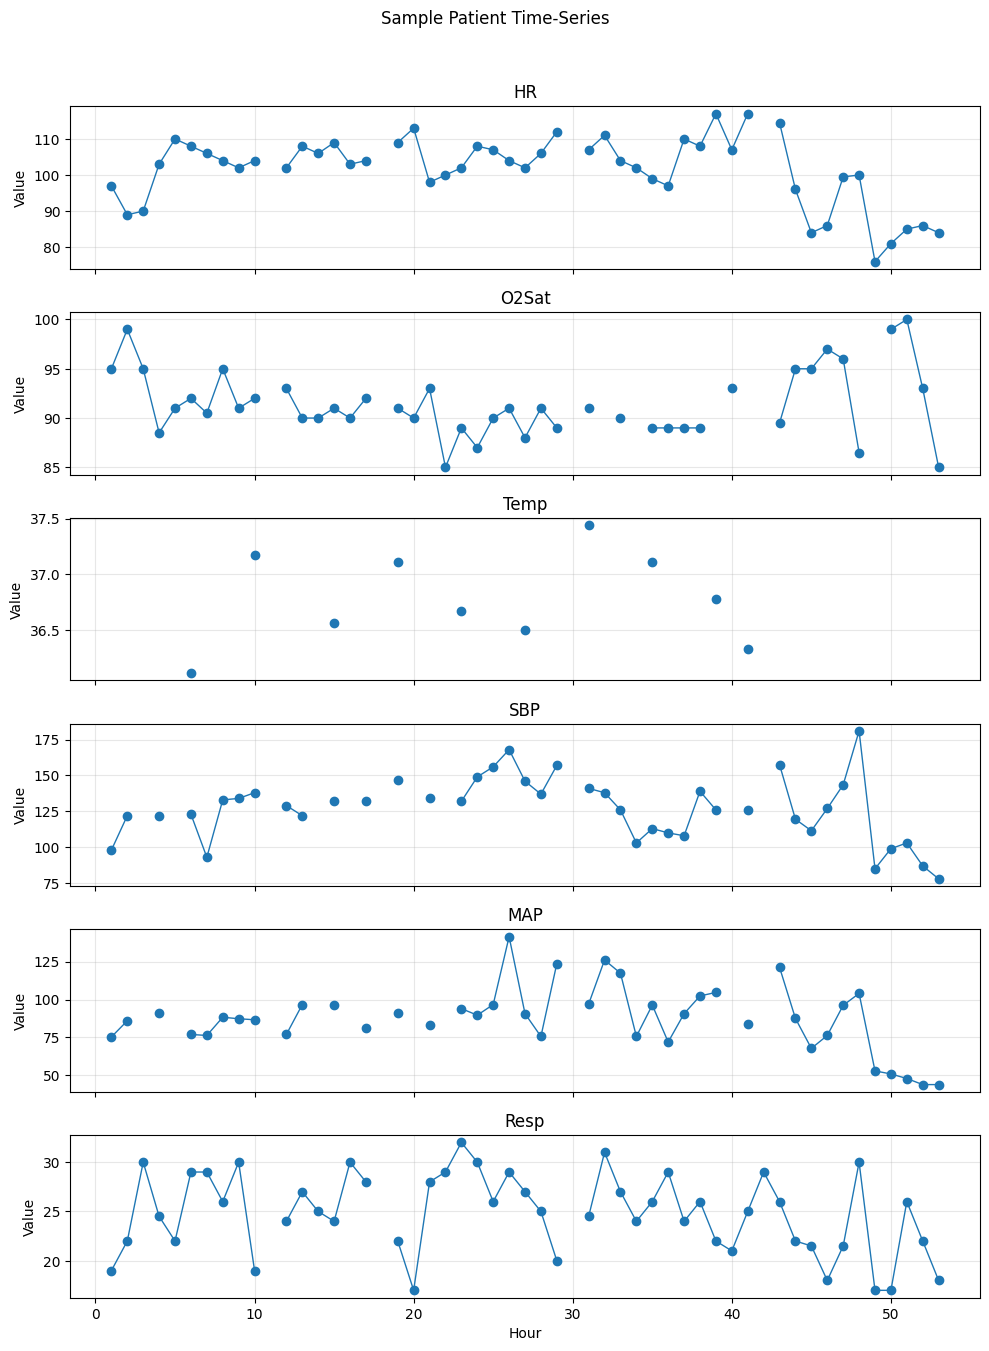

In [5]:
cols_to_plot = ["HR", "O2Sat", "Temp", "SBP", "MAP", "Resp"]

fig = plot_sample_patient_timeseries(
    sample_df,
    cols=cols_to_plot,
    save_path=RESULTS_FIGURES / "sample_patient_timeseries.png",
)

plt.show()

### 2.3. Patient-level dataset summary

Before creating prediction windows, we summarize each patient file:

- number of hourly observations
- whether the patient ever becomes septic
- first sepsis onset hour, if present
- cohort membership

This gives a patient-level view of dataset scale, ICU stay length, and sepsis prevalence.## 2.2. Patient-level summary

In [6]:
patient_summary_path = RESULTS_TABLES / "patient_summary.csv"

patient_summary = load_or_create_csv(
    patient_summary_path,
    create_fn=lambda: pd.concat(
        [
            build_patient_summary(files_a, cohort="A"),
            build_patient_summary(files_b, cohort="B"),
        ],
        ignore_index=True,
    ),
    force=FORCE_RECOMPUTE,
)

display(patient_summary.head())
print("Patient summary shape:", patient_summary.shape)

,patient_id,cohort,n_hours,has_sepsis,sepsis_onset_hour
0,p000001,A,54,0,NaN
1,p000002,A,23,0,NaN
2,p000003,A,48,0,NaN
3,p000004,A,29,0,NaN
4,p000005,A,48,0,NaN


Patient summary shape: (10000, 5)


### 2.4. Summary table

In [7]:
data_summary = (
    patient_summary
    .groupby("cohort")
    .agg(
        n_patients=("patient_id", "nunique"),
        mean_icu_hours=("n_hours", "mean"),
        median_icu_hours=("n_hours", "median"),
        min_icu_hours=("n_hours", "min"),
        max_icu_hours=("n_hours", "max"),
        n_sepsis_patients=("has_sepsis", "sum"),
        sepsis_prevalence=("has_sepsis", "mean"),
    )
    .reset_index()
)

overall = pd.DataFrame({
    "cohort": ["Overall"],
    "n_patients": [patient_summary["patient_id"].nunique()],
    "mean_icu_hours": [patient_summary["n_hours"].mean()],
    "median_icu_hours": [patient_summary["n_hours"].median()],
    "min_icu_hours": [patient_summary["n_hours"].min()],
    "max_icu_hours": [patient_summary["n_hours"].max()],
    "n_sepsis_patients": [patient_summary["has_sepsis"].sum()],
    "sepsis_prevalence": [patient_summary["has_sepsis"].mean()],
})

data_summary = pd.concat([data_summary, overall], ignore_index=True)

display(data_summary)

save_dataframe(
    data_summary,
    RESULTS_TABLES / "data_summary.csv",
    index=False,
)

,cohort,n_patients,mean_icu_hours,median_icu_hours,min_icu_hours,max_icu_hours,n_sepsis_patients,sepsis_prevalence
0,A,5000,38.9764,38.0,8,336,446,0.0892
1,B,5000,37.6972,38.0,8,336,279,0.0558
2,Overall,10000,38.3368,38.0,8,336,725,0.0725


## 3. Class balance

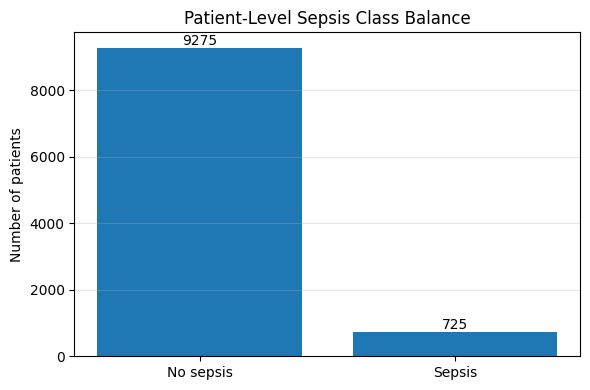

,has_sepsis,proportion
0,0,0.9275
1,1,0.0725


In [8]:
fig = plot_class_balance(
    patient_summary,
    save_path=RESULTS_FIGURES / "patient_level_class_balance.png",
)

plt.show()

patient_level_balance = (
    patient_summary["has_sepsis"]
    .value_counts(normalize=True)
    .sort_index()
    .rename_axis("has_sepsis")
    .reset_index(name="proportion")
)

display(patient_level_balance)

save_dataframe(
    patient_level_balance,
    RESULTS_TABLES / "patient_level_class_balance.csv",
    index=False,
)

## 4. Important Features
### 4.1. ICU stay length distribution

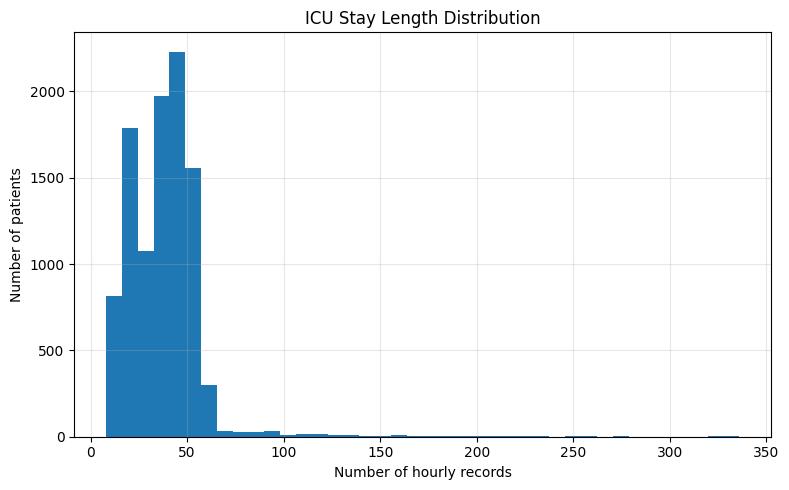

count    10000.000000
mean        38.336800
std         22.318853
min          8.000000
25%         24.000000
50%         38.000000
75%         47.000000
max        336.000000
Name: n_hours, dtype: float64

In [9]:
fig = plot_icu_length_distribution(
    patient_summary,
    save_path=RESULTS_FIGURES / "icu_length_distribution.png",
)

plt.show()

display(patient_summary["n_hours"].describe())

### 4.2. Sepsis onset hour distribution

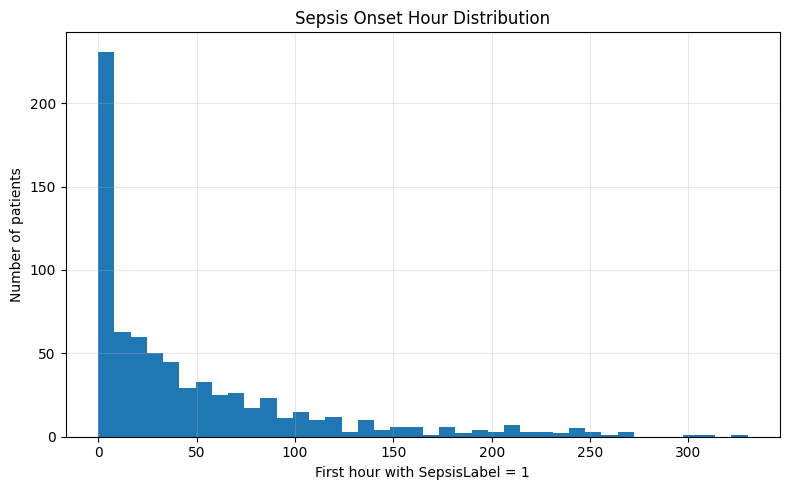

count    725.000000
mean      48.285517
std       59.948941
min        0.000000
25%        5.000000
50%       26.000000
75%       69.000000
max      330.000000
Name: sepsis_onset_hour, dtype: float64

In [10]:
fig = plot_sepsis_onset_distribution(
    patient_summary,
    save_path=RESULTS_FIGURES / "sepsis_onset_distribution.png",
)

plt.show()

sepsis_onset_description = (
    patient_summary
    .loc[patient_summary["has_sepsis"] == 1, "sepsis_onset_hour"]
    .describe()
)

display(sepsis_onset_description)

## 5. Prediction-window label prevalence

The later modeling task is not simply patient-level ever-sepsis classification.

Instead, the main pipeline will ask:

> Given information available up to prediction time `t`, does sepsis occur within the next prediction horizon?

This creates many rolling prediction windows per patient. The class imbalance at this window level is usually much more severe than the patient-level prevalence.

In [11]:
def create_window_level_summary():
    obs_cfg = cfg["temporal"]
    horizon = obs_cfg["prediction_horizon"]
    min_history = obs_cfg["min_history"]
    step_hours = obs_cfg["step_hours"]

    rows = []

    for cohort_name, files in [("A", files_a), ("B", files_b)]:
        for fp in files:
            df = read_patient_file(fp)

            prediction_times = generate_prediction_times(
                n_hours=len(df),
                min_history=min_history,
                step=step_hours,
            )

            for t in prediction_times:
                label = label_future_sepsis(df, t=t, horizon=horizon)

                # Exclude windows where the patient is already septic.
                if label is None:
                    continue

                rows.append({
                    "patient_id": df["patient_id"].iloc[0],
                    "cohort": cohort_name,
                    "prediction_time": t,
                    "future_sepsis": label,
                })

    return pd.DataFrame(rows)


window_summary = load_or_create_csv(
    RESULTS_TABLES / "window_level_label_summary.csv",
    create_fn=create_window_level_summary,
    force=FORCE_RECOMPUTE,
)

display(window_summary.head())
print("Window summary shape:", window_summary.shape)

,patient_id,cohort,prediction_time,future_sepsis
0,p000001,A,5,0
1,p000001,A,6,0
2,p000001,A,7,0
3,p000001,A,8,0
4,p000001,A,9,0


Window summary shape: (317868, 4)


### 5.1. Window-level class balance

In [12]:
window_balance = (
    window_summary
    .groupby("cohort")["future_sepsis"]
    .agg(
        n_windows="count",
        n_positive="sum",
        positive_rate="mean",
    )
    .reset_index()
)

overall_window = pd.DataFrame({
    "cohort": ["Overall"],
    "n_windows": [len(window_summary)],
    "n_positive": [window_summary["future_sepsis"].sum()],
    "positive_rate": [window_summary["future_sepsis"].mean()],
})

window_balance = pd.concat(
    [window_balance, overall_window],
    ignore_index=True,
)

display(window_balance)

save_dataframe(
    window_balance,
    RESULTS_TABLES / "window_level_class_balance.csv",
    index=False,
)

,cohort,n_windows,n_positive,positive_rate
0,A,161375,1929,0.011954
1,B,156493,1121,0.007163
2,Overall,317868,3050,0.009595


## 7. Prediction time distribution

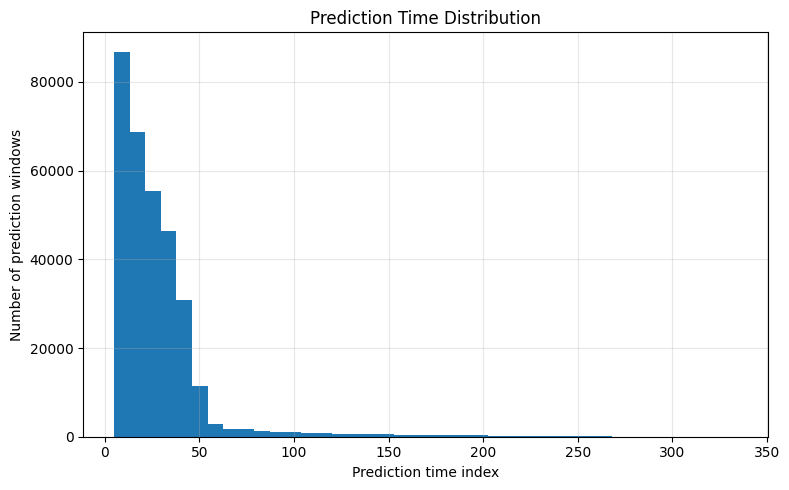

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(window_summary["prediction_time"], bins=40)
ax.set_title("Prediction Time Distribution")
ax.set_xlabel("Prediction time index")
ax.set_ylabel("Number of prediction windows")
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(
    RESULTS_FIGURES / "prediction_time_distribution.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Interpretation: patient-level vs window-level imbalance

The patient-level prevalence and prediction-window prevalence are different.

A patient may eventually become septic, but only a small number of hourly prediction windows occur shortly before future sepsis onset. Therefore, the actual early prediction task is much more imbalanced than patient-level classification.

This motivates:

- AUPRC rather than accuracy as a key metric
- precision/recall and threshold analysis
- imbalance-aware training strategies
- careful interpretation of false positives and false negatives

## 8. Raw missingness analysis

Clinical time-series data are not measured uniformly. Some variables are recorded frequently, while others are ordered only under specific clinical circumstances.

Missingness is therefore both:

1. a technical modeling problem, and  
2. a potential clinical/workflow signal.

This section summarizes missingness in the raw variables before feature engineering.

### 8.1. Missingness across selected fields

In [14]:
all_files = files_a + files_b

missing_summary = load_or_create_csv(
    RESULTS_TABLES / "missingness_summary_raw.csv",
    create_fn=lambda: compute_raw_missingness(all_files),
    force=FORCE_RECOMPUTE,
)

display(missing_summary.head(30))

,feature,missing_count,total_count,missing_fraction
0,Bilirubin_direct,382605,383368,0.998010
1,Fibrinogen,380771,383368,0.993226
2,TroponinI,379587,383368,0.990137
3,Bilirubin_total,377618,383368,0.985001
4,Alkalinephos,377139,383368,0.983752
5,AST,377082,383368,0.983603
6,Lactate,372966,383368,0.972867
7,PTT,372095,383368,0.970595
8,SaO2,369955,383368,0.965013
9,EtCO2,369715,383368,0.964387


### 8.2. Top missing raw variables

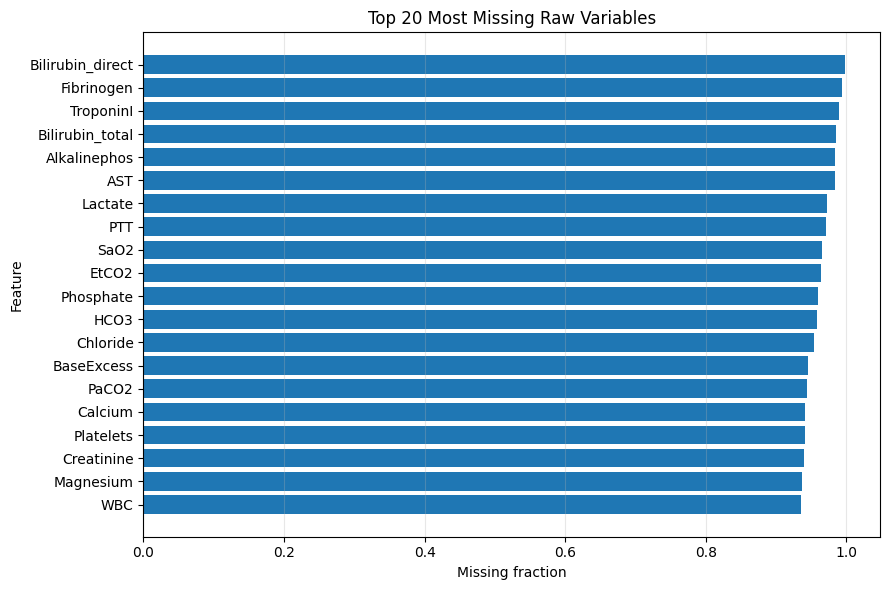

In [15]:
fig = plot_missingness_top_n(
    missing_summary,
    top_n=20,
    save_path=RESULTS_FIGURES / "raw_missingness_top20.png",
)

plt.show()

### 8.3. Missingness category

In [16]:
def categorize_missingness(frac):
    if frac < 0.20:
        return "low_missing_<20%"
    elif frac < 0.60:
        return "moderate_missing_20_60%"
    elif frac < 0.90:
        return "high_missing_60_90%"
    else:
        return "extreme_missing_90%+"


missing_summary["missing_category"] = missing_summary["missing_fraction"].apply(
    categorize_missingness
)

missing_category_summary = (
    missing_summary["missing_category"]
    .value_counts()
    .rename_axis("missing_category")
    .reset_index(name="n_features")
)

display(missing_category_summary)

save_dataframe(
    missing_category_summary,
    RESULTS_TABLES / "missingness_category_summary.csv",
    index=False,
)

,missing_category,n_features
0,extreme_missing_90%+,26
1,low_missing_<20%,10
2,moderate_missing_20_60%,3
3,high_missing_60_90%,2


### 8.4. More available variables

,feature,missing_count,total_count,missing_fraction,missing_category
36,Age,0,383368,0.000000,low_missing_<20%
37,Gender,0,383368,0.000000,low_missing_<20%
38,HospAdmTime,0,383368,0.000000,low_missing_<20%
40,SepsisLabel,0,383368,0.000000,low_missing_<20%
39,ICULOS,0,383368,0.000000,low_missing_<20%
35,HR,38355,383368,0.100047,low_missing_<20%
34,MAP,48320,383368,0.126041,low_missing_<20%
33,O2Sat,50257,383368,0.131093,low_missing_<20%
32,SBP,56817,383368,0.148205,low_missing_<20%
31,Resp,59745,383368,0.155842,low_missing_<20%


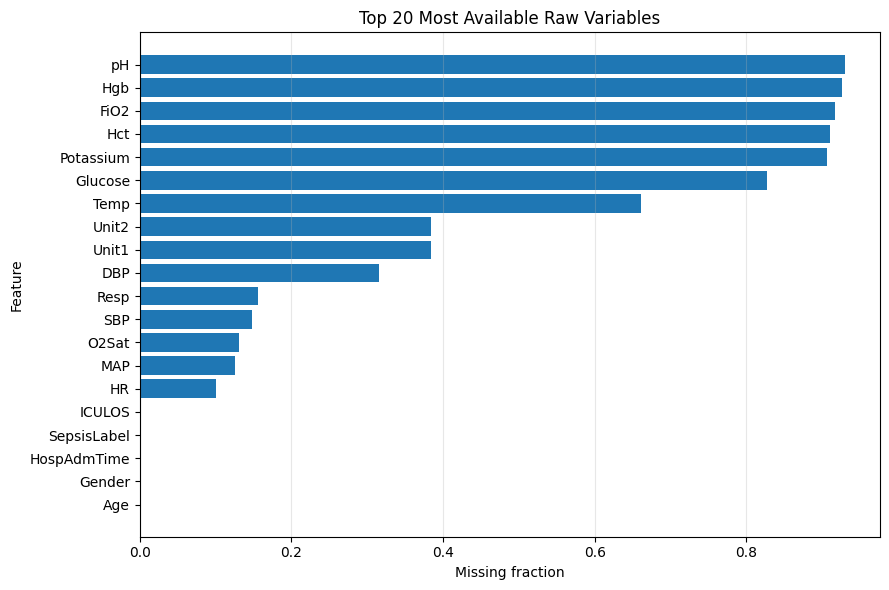

In [17]:
least_missing = (
    missing_summary
    .sort_values("missing_fraction", ascending=True)
    .head(20)
)

display(least_missing)

fig, ax = plt.subplots(figsize=(9, 6))

plot_df = least_missing.sort_values("missing_fraction", ascending=True)

ax.barh(plot_df["feature"], plot_df["missing_fraction"])
ax.set_title("Top 20 Most Available Raw Variables")
ax.set_xlabel("Missing fraction")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
fig.savefig(
    RESULTS_FIGURES / "raw_most_available_top20.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Interpretation: dense vs sparse variables

The raw feature space contains a small group of dense variables, mainly demographics and vital signs, and a much larger group of sparse laboratory or intervention-related variables.

This distinction matters for later feature engineering:

- dense vital signs can support value summaries and temporal trend features
- sparse laboratory variables may be unstable as raw value features
- missingness and measurement counts may themselves carry useful clinical or workflow signal

## 9. Cohort-specific missingness

The PhysioNet Challenge data include different training cohorts. If variables are measured or documented differently across cohorts, models may learn cohort-specific workflow patterns rather than generalizable physiology.

This section compares raw missingness between cohorts A and B.

In [18]:
missing_by_cohort = load_or_create_csv(
    RESULTS_TABLES / "missingness_by_cohort_raw.csv",
    create_fn=lambda: compute_missingness_by_cohort(files_a, files_b),
    force=FORCE_RECOMPUTE,
)

display(missing_by_cohort.head())

,feature,missing_count,total_count,missing_fraction,cohort
0,EtCO2,194882,194882,1.000000,A
1,TroponinI,194643,194882,0.998774,A
2,Bilirubin_direct,194555,194882,0.998322,A
3,Fibrinogen,193358,194882,0.992180,A
4,Bilirubin_total,192533,194882,0.987947,A


In [19]:
missing_pivot = (
    missing_by_cohort
    .pivot(index="feature", columns="cohort", values="missing_fraction")
    .reset_index()
)

missing_pivot["abs_difference"] = (
    missing_pivot["A"] - missing_pivot["B"]
).abs()

missing_pivot = missing_pivot.sort_values(
    "abs_difference",
    ascending=False,
)

display(missing_pivot.head(30))

save_dataframe(
    missing_pivot,
    RESULTS_TABLES / "missingness_cohort_difference.csv",
    index=False,
)

cohort,feature,A,B,abs_difference
10,DBP,0.484786,0.141071,0.343714
37,Unit1,0.479290,0.284721,0.194569
38,Unit2,0.479290,0.284721,0.194569
12,FiO2,0.857781,0.977622,0.119841
31,Resp,0.099927,0.213655,0.113728
4,BaseExcess,0.893977,0.997825,0.103848
15,Glucose,0.875822,0.777835,0.097987
40,pH,0.883550,0.977839,0.094289
16,HCO3,0.919254,0.998265,0.079011
8,Chloride,0.916642,0.993846,0.077204


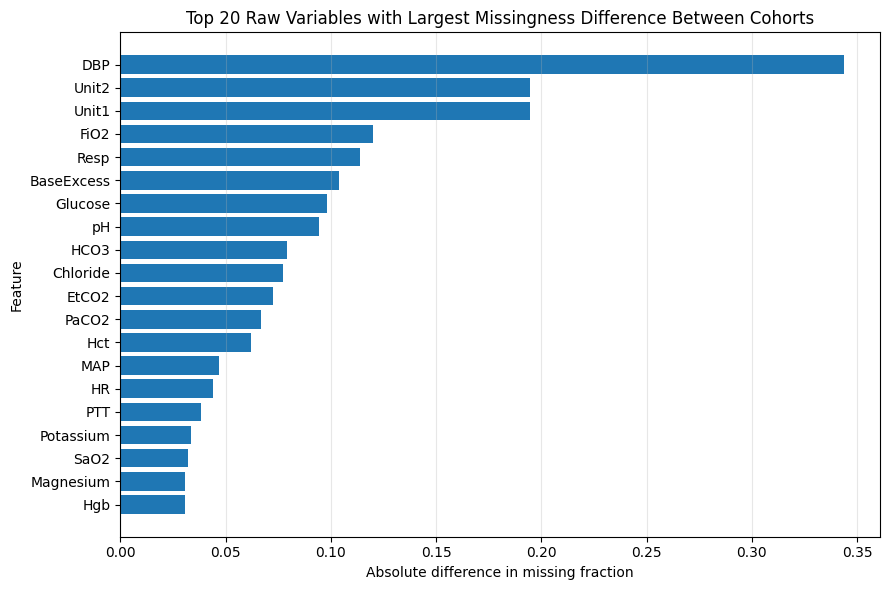

In [20]:
top_diff = missing_pivot.head(20).sort_values(
    "abs_difference",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(top_diff["feature"], top_diff["abs_difference"])
ax.set_title("Top 20 Raw Variables with Largest Missingness Difference Between Cohorts")
ax.set_xlabel("Absolute difference in missing fraction")
ax.set_ylabel("Feature")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
fig.savefig(
    RESULTS_FIGURES / "missingness_cohort_difference_top20.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Interpretation: cohort-dependent measurement

Large missingness differences between cohorts suggest possible differences in measurement practice, documentation, ICU type, or data extraction.

This motivates later robustness analysis, including:

- cohort-specific evaluation
- train-on-A/test-on-B experiments
- comparison of feature importance across cohorts
- careful interpretation of measurement-count and missingness features

## 10. Clinically focused variables

Not every raw variable needs deep individual analysis. For the rest of the project, we focus on a small group of variables that are clinically relevant and useful for feature engineering.

These include dense vital signs, sparse laboratory markers, and variables that may reflect clinical workflow or respiratory support.

In [21]:
clinical_focus_vars = [
    "HR",
    "O2Sat",
    "Temp",
    "MAP",
    "Resp",
    "SBP",
    "Lactate",
    "WBC",
    "Creatinine",
    "Platelets",
    "FiO2",
    "DBP",
]

available_features = set(missing_summary["feature"])
clinical_focus_vars = [v for v in clinical_focus_vars if v in available_features]

clinical_focus_vars

['HR',
 'O2Sat',
 'Temp',
 'MAP',
 'Resp',
 'SBP',
 'Lactate',
 'WBC',
 'Creatinine',
 'Platelets',
 'FiO2',
 'DBP']

### 10.1. Clinical focus missingness 

In [22]:
focus_missingness = (
    missing_summary
    .loc[missing_summary["feature"].isin(clinical_focus_vars)]
    .copy()
    .sort_values("missing_fraction", ascending=False)
)

clinical_interpretation = {
    "HR": "Dense vital sign; tachycardia may reflect physiological stress.",
    "O2Sat": "Dense vital sign; oxygenation and respiratory deterioration.",
    "Temp": "Fever/hypothermia signal; often intermittently measured.",
    "MAP": "Hemodynamic status; hypotension is clinically important.",
    "Resp": "Respiratory distress; relevant in sepsis deterioration.",
    "SBP": "Systolic blood pressure; part of qSOFA blood pressure criterion.",
    "Lactate": "Sepsis/severity marker, but sparse; measurement may reflect clinical suspicion.",
    "WBC": "Inflammation/infection marker; lab ordering may reflect suspicion.",
    "Creatinine": "Renal function and organ dysfunction marker.",
    "Platelets": "Coagulation and organ dysfunction marker.",
    "FiO2": "Respiratory support/oxygen therapy; may reflect workflow and severity.",
    "DBP": "Blood pressure component; notable cohort measurement differences.",
}

focus_missingness["clinical_note"] = focus_missingness["feature"].map(
    clinical_interpretation
)

display(focus_missingness[["feature", "missing_fraction", "clinical_note"]])

save_dataframe(
    focus_missingness[["feature", "missing_fraction", "clinical_note"]],
    RESULTS_TABLES / "clinical_focus_missingness_interpretation.csv",
    index=False,
)

,feature,missing_fraction,clinical_note
6,Lactate,0.972867,"Sepsis/severity marker, but sparse; measuremen..."
16,Platelets,0.940741,Coagulation and organ dysfunction marker.
17,Creatinine,0.939419,Renal function and organ dysfunction marker.
19,WBC,0.935939,Inflammation/infection marker; lab ordering ma...
23,FiO2,0.916701,Respiratory support/oxygen therapy; may reflec...
27,Temp,0.661148,Fever/hypothermia signal; often intermittently...
30,DBP,0.315796,Blood pressure component; notable cohort measu...
31,Resp,0.155842,Respiratory distress; relevant in sepsis deter...
32,SBP,0.148205,Systolic blood pressure; part of qSOFA blood p...
33,O2Sat,0.131093,Dense vital sign; oxygenation and respiratory ...


## 11. Measurement availability as a potential signal

For sparse clinical variables, the fact that a measurement was taken may itself be informative.

For example, lactate values are often missing, but lactate measurement may reflect clinical concern, severity, or a sepsis-related workup. This does not mean that measurement causes sepsis. It means the measurement process may encode information about patient state and clinical workflow.

This section compares observation rates between septic and non-septic patients for selected clinically relevant variables.

In [23]:
def compute_measurement_rate_by_patient(files, variables):
    rows = []

    for fp in files:
        df = read_patient_file(fp)

        row = {
            "patient_id": df["patient_id"].iloc[0],
            "n_hours": len(df),
            "has_sepsis": int(df["SepsisLabel"].max()),
        }

        for var in variables:
            if var in df.columns:
                row[f"{var}_observed_rate"] = df[var].notna().mean()
                row[f"{var}_observed_count"] = df[var].notna().sum()
            else:
                row[f"{var}_observed_rate"] = 0.0
                row[f"{var}_observed_count"] = 0

        rows.append(row)

    return pd.DataFrame(rows)

### 11.1. Measurement-rate table

In [24]:
measurement_focus = load_or_create_csv(
    RESULTS_TABLES / "clinical_focus_measurement_by_patient.csv",
    create_fn=lambda: compute_measurement_rate_by_patient(
        all_files,
        clinical_focus_vars,
    ),
    force=FORCE_RECOMPUTE,
)

display(measurement_focus.head())

,patient_id,n_hours,has_sepsis,HR_observed_rate,HR_observed_count,O2Sat_observed_rate,O2Sat_observed_count,Temp_observed_rate,Temp_observed_count,MAP_observed_rate,MAP_observed_count,Resp_observed_rate,Resp_observed_count,SBP_observed_rate,SBP_observed_count,Lactate_observed_rate,Lactate_observed_count,WBC_observed_rate,WBC_observed_count,Creatinine_observed_rate,Creatinine_observed_count,Platelets_observed_rate,Platelets_observed_count,FiO2_observed_rate,FiO2_observed_count,DBP_observed_rate,DBP_observed_count
0,p000001,54,0,0.907407,49,0.814815,44,0.185185,10,0.777778,42,0.925926,50,0.777778,42,0.0,0,0.037037,2,0.037037,2,0.037037,2,0.074074,4,0.000000,0
1,p000002,23,0,0.956522,22,0.956522,22,0.260870,6,0.956522,22,0.826087,19,0.652174,15,0.0,0,0.043478,1,0.043478,1,0.043478,1,0.000000,0,0.652174,15
2,p000003,48,0,0.937500,45,0.916667,44,0.333333,16,0.937500,45,0.937500,45,0.937500,45,0.0,0,0.062500,3,0.062500,3,0.062500,3,0.145833,7,0.875000,42
3,p000004,29,0,0.931034,27,0.931034,27,0.206897,6,0.896552,26,0.896552,26,0.896552,26,0.0,0,0.034483,1,0.068966,2,0.068966,2,0.000000,0,0.482759,14
4,p000005,48,0,0.500000,24,0.437500,21,0.187500,9,0.354167,17,0.437500,21,0.500000,24,0.0,0,0.062500,3,0.062500,3,0.062500,3,0.000000,0,0.000000,0


### 11.2. Measurement rate by sepsis status

In [25]:
rate_cols = [f"{v}_observed_rate" for v in clinical_focus_vars]

measurement_by_sepsis = (
    measurement_focus
    .groupby("has_sepsis")[rate_cols]
    .mean()
    .T
    .reset_index()
)

measurement_by_sepsis.columns = [
    "feature",
    "non_sepsis_observed_rate",
    "sepsis_observed_rate",
]

measurement_by_sepsis["feature"] = measurement_by_sepsis["feature"].str.replace(
    "_observed_rate",
    "",
    regex=False,
)

measurement_by_sepsis["difference_sepsis_minus_nonsepsis"] = (
    measurement_by_sepsis["sepsis_observed_rate"]
    - measurement_by_sepsis["non_sepsis_observed_rate"]
)

measurement_by_sepsis = measurement_by_sepsis.sort_values(
    "difference_sepsis_minus_nonsepsis",
    ascending=False,
)

display(measurement_by_sepsis)

save_dataframe(
    measurement_by_sepsis,
    RESULTS_TABLES / "clinical_focus_measurement_by_sepsis.csv",
    index=False,
)

,feature,non_sepsis_observed_rate,sepsis_observed_rate,difference_sepsis_minus_nonsepsis
10,FiO2,0.068391,0.169898,0.101507
6,Lactate,0.022626,0.069967,0.047342
3,MAP,0.859372,0.891118,0.031746
1,O2Sat,0.855009,0.884564,0.029555
7,WBC,0.063394,0.084563,0.021169
0,HR,0.887795,0.908711,0.020916
11,DBP,0.667267,0.687160,0.019893
8,Creatinine,0.060146,0.075798,0.015652
9,Platelets,0.058920,0.074188,0.015268
4,Resp,0.833271,0.845360,0.012090


### 11.3. Measurement-rate difference

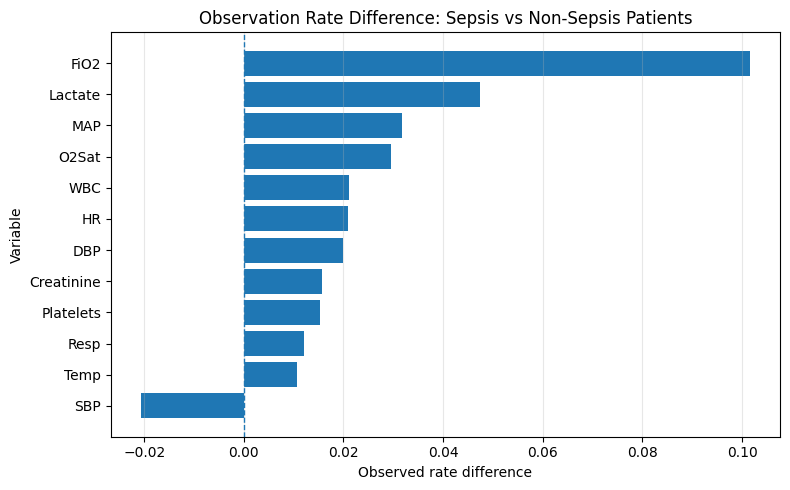

In [26]:
plot_df = measurement_by_sepsis.sort_values(
    "difference_sepsis_minus_nonsepsis",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_df["feature"],
    plot_df["difference_sepsis_minus_nonsepsis"],
)

ax.axvline(0, linestyle="--", linewidth=1)
ax.set_title("Observation Rate Difference: Sepsis vs Non-Sepsis Patients")
ax.set_xlabel("Observed rate difference")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.3)

fig.tight_layout()
fig.savefig(
    RESULTS_FIGURES / "clinical_focus_observation_difference_sepsis.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

### Interpretation: measurement availability

If a variable is measured more often among septic patients, this should not be interpreted causally. Instead, measurement availability may reflect:

- clinical suspicion
- patient severity
- monitoring intensity
- ICU workflow
- cohort-specific documentation practices

This motivates later feature engineering with both physiological value features and measurement-process features such as missingness fractions and observation counts.

## 12. qSOFA-like and SOFA-inspired variables

The project will not attempt to reconstruct official SOFA or qSOFA scores.

However, clinically motivated features inspired by qSOFA/SOFA can be useful because they connect model inputs to known clinical reasoning.

Important distinction:

- qSOFA-like features are **not official qSOFA**, because altered mental status/GCS is unavailable.
- SOFA-inspired features are **not official SOFA**, because several required components such as GCS, vasopressor dose, urine output, and full PaO2/FiO2 scoring are unavailable or sparse.

The goal is to create interpretable clinical proxy features later, not to claim official clinical scoring.

In [27]:
clinical_score_variables = pd.DataFrame([
    {
        "clinical_concept": "qSOFA respiratory criterion",
        "available_variable": "Resp",
        "planned_feature": "Resp >= 22 count / last / max",
        "limitation": "Available, but measurement frequency varies.",
    },
    {
        "clinical_concept": "qSOFA systolic blood pressure criterion",
        "available_variable": "SBP",
        "planned_feature": "SBP <= 100 count / last / min",
        "limitation": "Available, but missingness varies by patient.",
    },
    {
        "clinical_concept": "qSOFA altered mental status criterion",
        "available_variable": "Not available",
        "planned_feature": "Not included",
        "limitation": "GCS or mental status is not present in the dataset.",
    },
    {
        "clinical_concept": "SOFA cardiovascular component",
        "available_variable": "MAP",
        "planned_feature": "MAP < 70 count / min / last",
        "limitation": "Vasopressor use is unavailable, so full SOFA cardiovascular scoring is not possible.",
    },
    {
        "clinical_concept": "SOFA coagulation component",
        "available_variable": "Platelets",
        "planned_feature": "Platelet summary and low platelet indicator",
        "limitation": "Sparse laboratory variable.",
    },
    {
        "clinical_concept": "SOFA liver component",
        "available_variable": "Bilirubin_total / Bilirubin_direct",
        "planned_feature": "Bilirubin summary or measured indicator",
        "limitation": "Extremely sparse; value-based features may be unstable.",
    },
    {
        "clinical_concept": "SOFA renal component",
        "available_variable": "Creatinine",
        "planned_feature": "Creatinine summary and high creatinine indicator",
        "limitation": "Urine output is unavailable; only partial renal proxy.",
    },
    {
        "clinical_concept": "Respiratory support / oxygenation proxy",
        "available_variable": "O2Sat, FiO2, SaO2",
        "planned_feature": "O2Sat low count, FiO2 measured/count",
        "limitation": "PaO2 is unavailable; full PaO2/FiO2 SOFA respiratory score is not possible.",
    },
    {
        "clinical_concept": "Sepsis severity / hypoperfusion marker",
        "available_variable": "Lactate",
        "planned_feature": "Lactate measured, lactate high if available",
        "limitation": "Very sparse; measurement may reflect clinical suspicion.",
    },
    {
        "clinical_concept": "Inflammation / infection marker",
        "available_variable": "WBC",
        "planned_feature": "WBC abnormal count / last / measured",
        "limitation": "Sparse lab variable; not specific to sepsis.",
    },
])

display(clinical_score_variables)

save_dataframe(
    clinical_score_variables,
    RESULTS_TABLES / "clinical_score_variable_mapping.csv",
    index=False,
)

,clinical_concept,available_variable,planned_feature,limitation
0,qSOFA respiratory criterion,Resp,Resp >= 22 count / last / max,"Available, but measurement frequency varies."
1,qSOFA systolic blood pressure criterion,SBP,SBP <= 100 count / last / min,"Available, but missingness varies by patient."
2,qSOFA altered mental status criterion,Not available,Not included,GCS or mental status is not present in the dat...
3,SOFA cardiovascular component,MAP,MAP < 70 count / min / last,"Vasopressor use is unavailable, so full SOFA c..."
4,SOFA coagulation component,Platelets,Platelet summary and low platelet indicator,Sparse laboratory variable.
5,SOFA liver component,Bilirubin_total / Bilirubin_direct,Bilirubin summary or measured indicator,Extremely sparse; value-based features may be ...
6,SOFA renal component,Creatinine,Creatinine summary and high creatinine indicator,Urine output is unavailable; only partial rena...
7,Respiratory support / oxygenation proxy,"O2Sat, FiO2, SaO2","O2Sat low count, FiO2 measured/count",PaO2 is unavailable; full PaO2/FiO2 SOFA respi...
8,Sepsis severity / hypoperfusion marker,Lactate,"Lactate measured, lactate high if available",Very sparse; measurement may reflect clinical ...
9,Inflammation / infection marker,WBC,WBC abnormal count / last / measured,Sparse lab variable; not specific to sepsis.


## Final notes

### Main observations

1. The dataset contains irregular ICU time-series with variable patient trajectory length.
2. Patient-level sepsis prevalence is higher than future prediction-window prevalence.
3. The actual early prediction task is extremely imbalanced at the window level.
4. Missingness is substantial, especially for laboratory variables.
5. Missingness differs across cohorts, suggesting possible workflow or documentation shift.
6. Some clinically relevant variables are sparse but still important because measurement itself may carry signal.
7. qSOFA-like and SOFA-inspired features can be created later, but they should be treated as proxy features rather than official clinical scores.

### Modeling implications

- Use patient-level splitting to avoid leakage between repeated windows from the same patient.
- Use AUPRC, precision, recall, and calibration rather than accuracy.
- Include missingness and measurement-count features in later feature engineering.
- Treat qSOFA-like and SOFA-inspired features as clinically motivated proxies, not official diagnostic scores.
- Evaluate cohort robustness because cohorts A and B differ in measurement patterns.
- Be careful not to interpret measurement availability as purely physiological signal.

### Next step

The next notebook builds a simple baseline model using patient-level temporal summaries before moving to the full leakage-aware rolling-window pipeline.